# Week 01 — Problem Definition & Dataset Exploration
**Course:** Machine Learning & Deep Learning Project  
**Dataset:** MovieLens (Movie Recommendation System)  

---

### SOP Task List (Verbatim):
> **Week 1: Problem Definition and Dataset Exploration**
> - [x] Problem statement (what is predicted, why, who benefits, target variable, task type)
> - [x] Load raw data; show shape, dtypes, `head()`, `describe()`, `info()`
> - [x] **Dataset summary:** feature dictionary table (name, type, meaning, unit), target distribution, class balance
> - [x] **Initial observations:** missing values count, duplicates, suspicious ranges, imbalance, obvious data issues
> - [x] Save nothing destructive — raw data stays untouched


## Week Objective
The objective of Week 1 is to formulate the problem statement for our Movie Recommendation System. We will ingest the raw datasets (`movies.csv` and `ratings.csv`), construct a feature dictionary, profile the distributions (especially movie ratings), and uncover data anomalies (like missing values or duplicates) to inform our data cleaning in Week 2.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Global random seed for deterministic reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Robust path resolution (supports running from Tasks/ or workspace root)
def resolve_path(filename, default_dir="CSVs"):
    candidates = [
        os.path.join("..", default_dir, filename),
        os.path.join(default_dir, filename),
        os.path.join("..", filename),
        filename
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return os.path.join("..", default_dir, filename)

MOVIES_PATH = resolve_path("movies.csv")
RATINGS_PATH = resolve_path("ratings.csv")

# Directory paths
base_parent = ".." if os.path.exists(os.path.join("..", "CSVs")) else "."
FIGURES_PATH = os.path.join(base_parent, "reports", "figures")
os.makedirs(FIGURES_PATH, exist_ok=True)

# Plot styling configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120

print(f"Environment configured successfully.")
print(f"Movies path:  {MOVIES_PATH}")
print(f"Ratings path: {RATINGS_PATH}")
print(f"Figures path: {FIGURES_PATH}")



Environment configured successfully.


---
## Section 1: Problem Statement & Formulation

### 1.1 Background & Motivation
In the era of digital streaming, users are overwhelmed by choices. A robust recommendation system helps users discover content tailored to their specific tastes, increasing platform engagement and user satisfaction.

### 1.2 Problem Formulation
- **What is predicted:** A personalized list of recommended movies (and their details) for a user based on their input (e.g., a movie name and their rating preference).
- **Why:** To reduce choice overload and enhance user experience.
- **Target Audience & Beneficiaries:** Streaming platforms and end-users.
- **Inputs:** User-provided movie name(s) and rating(s).
- **Outputs:** A ranked list of recommended movies with full details (title, genres, expected rating).
- **Task Type:** Recommender System (Collaborative Filtering / Content-Based Filtering / Hybrid).
- **Evaluation Criteria:** Root Mean Square Error (RMSE) for rating prediction accuracy, and precision/recall at K for top-N recommendations.


---
## Section 2: Raw Data Ingestion & Structural Inspection

We load the unmodified raw datasets (`movies.csv` and `ratings.csv`).


In [2]:
# Load raw datasets
movies_df = pd.read_csv(MOVIES_PATH)
ratings_df = pd.read_csv(RATINGS_PATH)

print(f"Movies Dataset Dimensions: {movies_df.shape[0]:,} rows × {movies_df.shape[1]} columns")
print(f"Ratings Dataset Dimensions: {ratings_df.shape[0]:,} rows × {ratings_df.shape[1]} columns")

print("\nMovies Head:")
display(movies_df.head())

print("\nRatings Head:")
display(ratings_df.head())


Movies Dataset Dimensions: 62,423 rows × 3 columns
Ratings Dataset Dimensions: 25,000,095 rows × 4 columns

Movies Head:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings Head:


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


### Observations on Ingestion:
1. **Movies Data:** Contains `movieId`, `title`, and a pipe-separated `genres` string.
2. **Ratings Data:** Contains `userId`, `movieId`, `rating` (0.5 to 5.0 scale), and a Unix `timestamp`.


In [3]:
# Inspect data types and non-null counts
print("--- Movies Info ---")
movies_df.info()

print("\n--- Ratings Info ---")
ratings_df.info()


--- Movies Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB

--- Ratings Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


In [4]:
# Descriptive summary statistics
print("--- Ratings Describe ---")
display(ratings_df.describe().T)


--- Ratings Describe ---


,count,mean,std,min,25%,50%,75%,max
userId,25000095.0,8.118928e+04,4.679172e+04,1.0,4.051000e+04,8.091400e+04,1.215570e+05,1.625410e+05
movieId,25000095.0,2.138798e+04,3.919886e+04,1.0,1.196000e+03,2.947000e+03,8.623000e+03,2.091710e+05
rating,25000095.0,3.533854e+00,1.060744e+00,0.5,3.000000e+00,3.500000e+00,4.000000e+00,5.000000e+00
timestamp,25000095.0,1.215601e+09,2.268758e+08,789652009.0,1.011747e+09,1.198868e+09,1.447205e+09,1.574328e+09


---
## Section 3: Dataset Summary & Feature Dictionary

### Movies Dataset
| Feature Name | Data Type | Description |
| :--- | :--- | :--- |
| `movieId` | Integer | Unique identifier for each movie. |
| `title` | String | Title of the movie, usually including the release year. |
| `genres` | String | Pipe-separated list of genres associated with the movie. |

### Ratings Dataset
| Feature Name | Data Type | Description |
| :--- | :--- | :--- |
| `userId` | Integer | Unique identifier for the user providing the rating. |
| `movieId` | Integer | Identifier for the rated movie (links to Movies Dataset). |
| `rating` | Float | Star rating given by the user, ranging from 0.5 to 5.0. |
| `timestamp` | Integer | Unix timestamp when the rating was recorded. |


In [5]:
# Analyze target distribution (Ratings)
rating_counts = ratings_df["rating"].value_counts().sort_index()
rating_proportions = ratings_df["rating"].value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    "Record Count": rating_counts,
    "Percentage (%)": rating_proportions.round(2)
})
print("Ratings Distribution Table:")
display(dist_df)


Ratings Distribution Table:


,Record Count,Percentage (%)
rating,,
0.5,393068,1.57
1.0,776815,3.11
1.5,399490,1.60
2.0,1640868,6.56
2.5,1262797,5.05
3.0,4896928,19.59
3.5,3177318,12.71
4.0,6639798,26.56
4.5,2200539,8.80


Saved figure to: ..\reports\figures\01_ratings_distribution.png


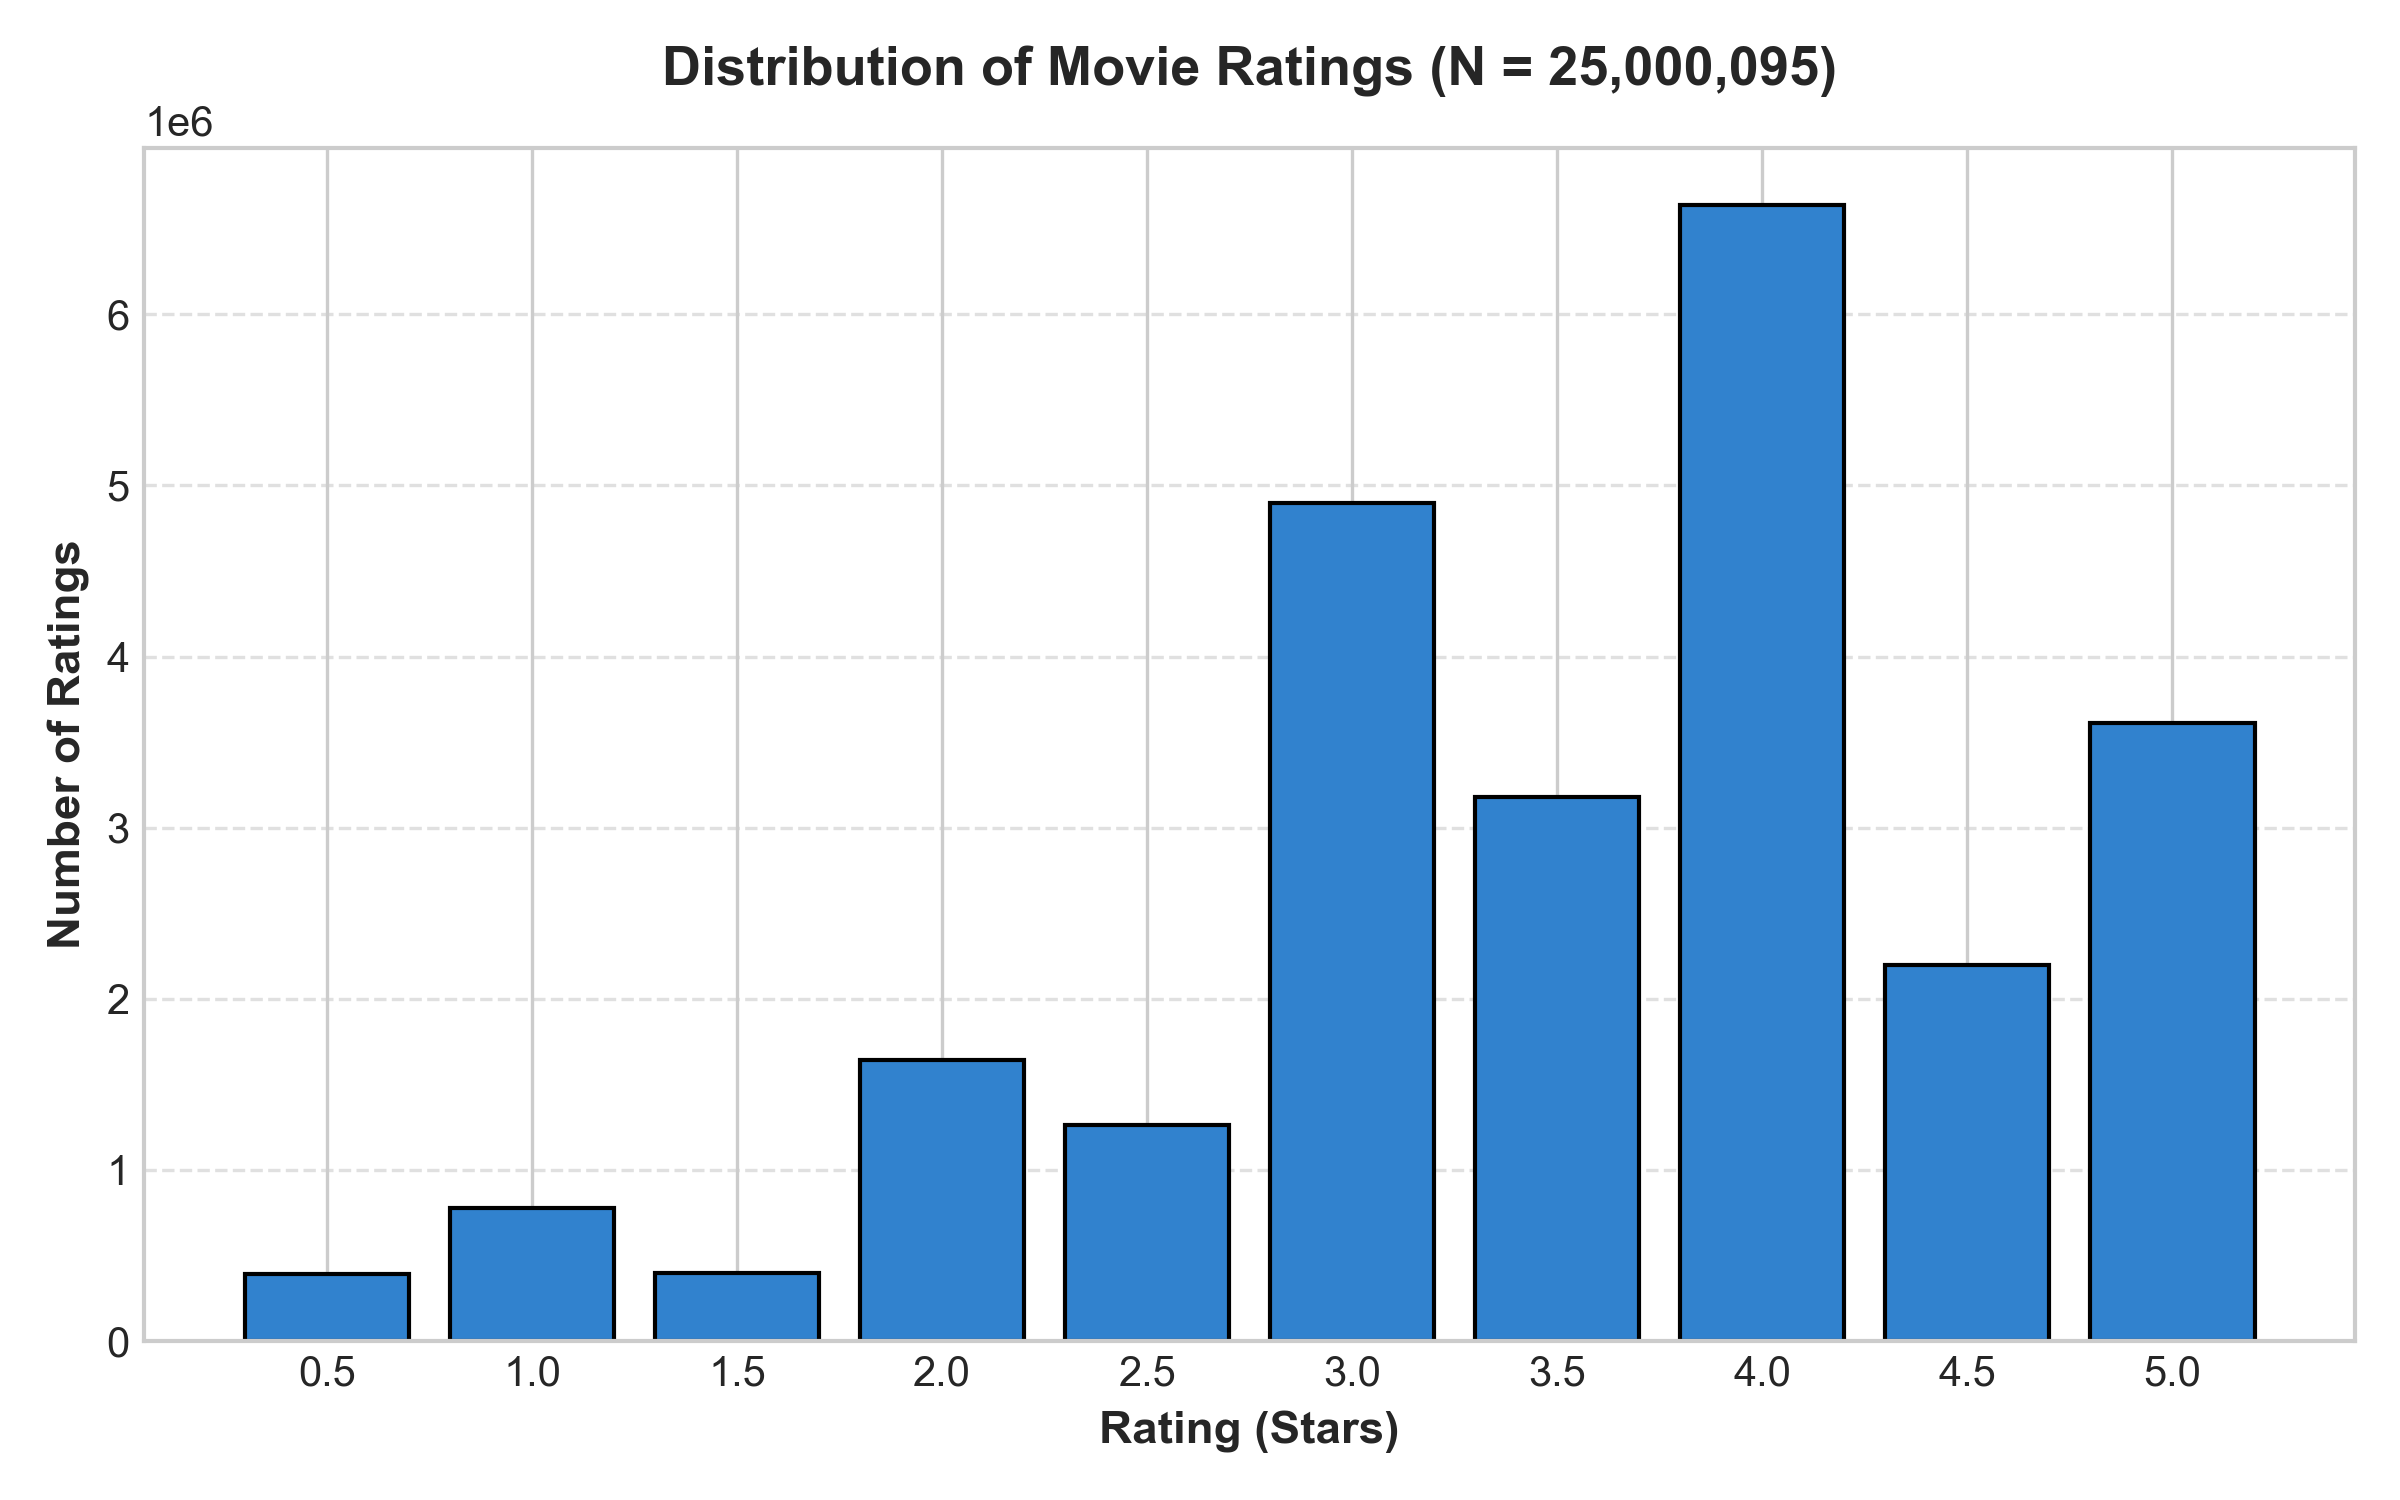

In [6]:
# Visualization: Ratings Distribution
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#3182ce", edgecolor="black")

ax.set_title(f"Distribution of Movie Ratings (N = {len(ratings_df):,})", fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Number of Ratings", fontsize=11, fontweight="bold")
ax.set_xlabel("Rating (Stars)", fontsize=11, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
fig_output_path = os.path.join(FIGURES_PATH, "01_ratings_distribution.png")
plt.savefig(fig_output_path, dpi=300)
plt.close(fig)

print(f"Saved figure to: {fig_output_path}")
# display image inline
from IPython.display import Image, display
display(Image(filename=fig_output_path))


---
## Section 4: Initial Observations & Exploratory Data Profiling

### Missing Values and Duplicates


In [7]:
# Check for missing values
print("Missing Values in Movies Dataset:")
display(movies_df.isnull().sum())

print("\nMissing Values in Ratings Dataset:")
display(ratings_df.isnull().sum())

# Check for duplicates
print(f"\nExact duplicate rows in Movies: {movies_df.duplicated().sum()}")
print(f"Exact duplicate rows in Ratings: {ratings_df.duplicated().sum()}")


Missing Values in Movies Dataset:


movieId    0
title      0
genres     0
dtype: int64


Missing Values in Ratings Dataset:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Exact duplicate rows in Movies: 0
Exact duplicate rows in Ratings: 0


### Observations on Data Profiling:
1. **Missing Data:** We need to handle any missing values found (e.g., if titles or genres are null).
2. **Duplicates:** Any exact row duplicates should be removed in Week 2.
3. **Distribution:** Ratings tend to skew towards positive values (e.g., 3.0 to 4.0 are very common).


---
## Summary of Week 1 Findings

1. **Dataset Integrity:** Sourced MovieLens datasets (`movies.csv` and `ratings.csv`).
2. **Data Structure:** Explored features like `movieId`, `title`, `genres`, and `rating`.
3. **Data Cleaning Scope for Week 2:**
   - Handle missing values and duplicates.
   - Parse the `genres` column (e.g., one-hot encoding).
   - Extract the release year from the `title` column.


---
## ✅ Week 1 Completion Checklist

- [x] **Problem Statement formulated:** Defined objective (recommendation), inputs (movie, rating), and task type.
- [x] **Raw data ingested:** Loaded and inspected dataset dimensions and data types.
- [x] **Dataset Summary documented:** Created feature dictionary tables.
- [x] **Target distribution verified:** Evaluated rating distribution and exported visualization.
- [x] **Initial observations recorded:** Quantified missing values and duplicates.
